# QSAR Model Development v2 (Full-data Training and Prediction of New Compounds)
## RDKit + Mordred + Morgan FP + MACCS | Nested CV | Optuna | RF / XGBoost / CatBoost / LightGBM

| Item | Description |
|---|---|
| **Descriptors** | RDKit, Mordred, Morgan fingerprints, and MACCS keys can be selected independently |
| **Data split** | No independent test split; the final model is trained using the full dataset |
| **Nested CV** | Performed using the full dataset to estimate internal predictive performance |
| **Reproducibility** | Random seeds are fixed hierarchically across folds, trials, and inner folds |
| **Algorithm selection** | The algorithm selected most frequently across the outer folds is used; mean AUC is used to break ties |
| **Trial records** | Algorithm selections from all Optuna trials are saved to `all_trials.csv` |
| **Output directory** | All files are saved to `RESULTS_DIR`, defined in Section 1 |

### Descriptor-set selection (configured in Section 1)

| Descriptor set | Variable | Approximate number of features | Description |
|---|---|---:|---|
| RDKit | `USE_RDKIT` | 200 | Physicochemical properties, including molecular weight and LogP |
| Mordred | `USE_MORDRED` | 1,800 | Topological, electronic, and geometrical descriptors |
| Morgan FP | `USE_MORGAN` | 2,048 | Local chemical environments and substructures (ECFP4/6) |
| MACCS Keys | `USE_MACCS` | 167 | Presence or absence of predefined functional groups and fragments |


## 0. Library Imports


In [1]:
# !pip install rdkit-pypi mordred optuna xgboost catboost lightgbm shap tqdm joblib --quiet

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import joblib, json, time

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem import Descriptors, AllChem, MACCSkeys
    from rdkit.Chem import RDKFingerprint
    from rdkit.ML.Descriptors import MoleculeDescriptors
    from mordred import Calculator, descriptors as mordred_descs
    RDKIT_AVAILABLE = True
    import rdkit, mordred
    print(f'  RDKit={rdkit.__version__}  Mordred={mordred.__version__}')
except ImportError:
    RDKIT_AVAILABLE = False
    print('  ⚠️  RDKit and/or Mordred are not installed')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    matthews_corrcoef, balanced_accuracy_score, accuracy_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8F9FA',
                     'axes.grid':True,'grid.alpha':0.3})
PALETTE = {'RandomForest':'#5B8DEF','XGBoost':'#E84855',
           'CatBoost':'#2EC4B6','LightGBM':'#FF9F1C'}

import xgboost, catboost, lightgbm
print('✅ Library imports completed')
print(f'   Optuna={optuna.__version__}  XGBoost={xgboost.__version__}')
print(f'   CatBoost={catboost.__version__}  LightGBM={lightgbm.__version__}')
print(f'   SHAP={shap.__version__}')


  RDKit=2025.03.6  Mordred=1.2.0
✅ Library imports completed
   Optuna=4.5.0  XGBoost=3.1.3
   CatBoost=1.2.8  LightGBM=4.6.0
   SHAP=0.46.0


## 1. Configuration


In [2]:
# ─── Output directory ──────────────────────────────────────────
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'

# ─── Data input ────────────────────────────────────────────────
COMPUTE_DESCRIPTORS = False
RAW_DATA_PATH       = DATA_DIR / '20260407_BDB_GR_cSMILES_pKi_dedup_descriptors_computed.csv'
SMILES_COL          = 'canonical_SMILES'
PKI_COL             = 'pKi'
DESC_SAVE_PATH      = DATA_DIR / '20260407_BDB_GR_cSMILES_pKi_dedup_descriptors_computed.csv'
PRECOMPUTED_PATH    = DATA_DIR / '20260407_BDB_GR_cSMILES_pKi_dedup_descriptors_computed.csv'

# ─── Descriptor-set selection ────────────────────────────────────────────
# Set at least one descriptor set to True
USE_RDKIT   = False   # RDKit descriptors       (~200)   physicochemical properties
USE_MORDRED = True   # Mordred descriptors     (~1,800) topological and electronic properties
USE_MORGAN  = False   # Morgan FP (ECFP4) (2,048 bits) local chemical environments and substructures
USE_MACCS   = False   # MACCS Keys        (166 bits) functional groups and fragments

# Morgan fingerprint settings (used when USE_MORGAN=True)
MORGAN_RADIUS = 2    # 2=ECFP4 / 3=ECFP6
MORGAN_NBITS  = 2048

# ─── Modeling ─────────────────────────────────────────────────
PKI_THRESHOLD = 8.0
OUTER_SPLITS  = 5
INNER_SPLITS  = 5
N_TRIALS      = 50
K_MIN         = 10
K_MAX         = 300
MORDRED_3D    = False

# ─── Interpretation and prediction ────────────────────────────────────────────────
SHAP_SAMPLES = 200
AD_K         = 5

# ── Validation ────────────────────────────────────────────
if not any([USE_RDKIT, USE_MORDRED, USE_MORGAN, USE_MACCS]):
    raise ValueError('Select at least one descriptor set')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
desc_selected = [n for n,f in [('RDKit',USE_RDKIT),('Mordred',USE_MORDRED),
                                ('Morgan',USE_MORGAN),('MACCS',USE_MACCS)] if f]
print('✅ Configuration completed (v2: full-data training)')
print(f'   📁 Output directory: {RESULTS_DIR.as_posix()}')
print(f'   Descriptor sets : {" + ".join(desc_selected)}')
print(f'   Outer={OUTER_SPLITS} / Inner={INNER_SPLITS} / Trials={N_TRIALS} / K=[{K_MIN},{K_MAX}]')


✅ Configuration completed (v2: full-data training)
   📁 Output directory: ../results
   Descriptor sets : Mordred
   Outer=5 / Inner=5 / Trials=50 / K=[10,300]


## 2. Data Loading and Class-label Definition


📂 [Mode B] Loading the precomputed-descriptor CSV...
   Rows loaded: 1,204

Class distribution:
  High-affinity (1, pKi >= 8.0): 516 (42.9%)
  Non-high-affinity (0, pKi < 8.0) : 688 (57.1%)


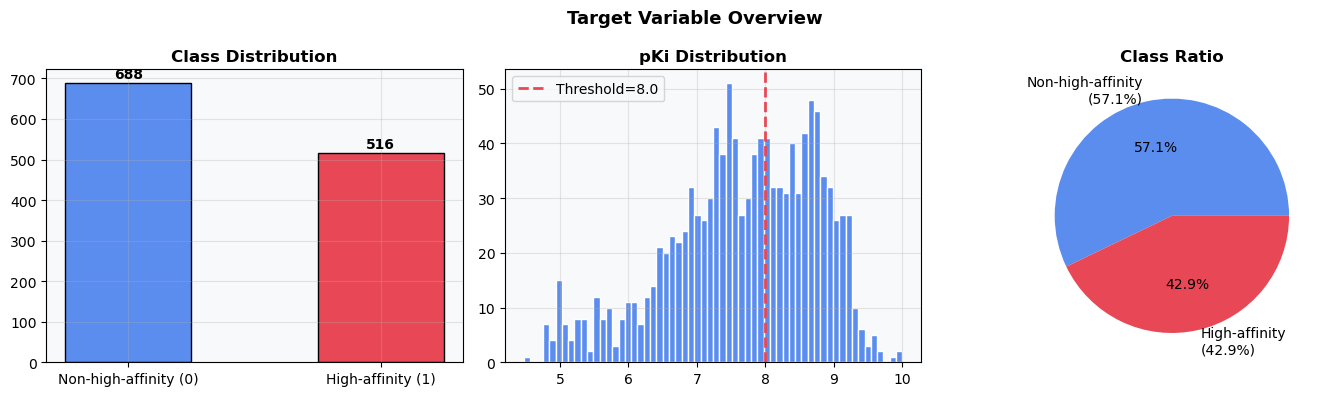

In [3]:
if COMPUTE_DESCRIPTORS:
    print('📂 [Mode A] Loading raw data and validating SMILES...')
    df_raw = pd.read_csv(RAW_DATA_PATH)
    df = df_raw[[SMILES_COL, PKI_COL]].dropna().copy()
    df = df[df[PKI_COL].apply(lambda x: isinstance(x, (int, float)))].copy()

    def is_valid_smiles(smi):
        try: return Chem.MolFromSmiles(str(smi)) is not None
        except: return False

    print('   Validating SMILES...')
    valid_mask = df[SMILES_COL].apply(is_valid_smiles)
    n_invalid  = (~valid_mask).sum()
    df = df[valid_mask].reset_index(drop=True)
    print(f'   Invalid SMILES removed: {n_invalid}')
    print(f'   Valid compounds: {len(df):,}')
else:
    print('📂 [Mode B] Loading the precomputed-descriptor CSV...')
    df_precomp = pd.read_csv(PRECOMPUTED_PATH)
    missing = [c for c in [SMILES_COL, PKI_COL] if c not in df_precomp.columns]
    if missing:
        raise ValueError(f'Required columns were not found: {missing}')
    df = df_precomp[[SMILES_COL, PKI_COL]].dropna(subset=[PKI_COL]).reset_index(drop=True)
    print(f'   Rows loaded: {len(df):,}')

df['label'] = (df[PKI_COL] >= PKI_THRESHOLD).astype(int)
vc = df['label'].value_counts()
print(f'\nClass distribution:')
print(f'  High-affinity (1, pKi >= {PKI_THRESHOLD}): {vc.get(1,0):,} ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  Non-high-affinity (0, pKi < {PKI_THRESHOLD}) : {vc.get(0,0):,} ({vc.get(0,0)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(['Non-high-affinity (0)','High-affinity (1)'], [vc.get(0,0),vc.get(1,0)],
            color=['#5B8DEF','#E84855'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
[axes[0].text(i, v+len(df)*0.01, f'{v:,}', ha='center', fontweight='bold')
 for i,v in enumerate([vc.get(0,0),vc.get(1,0)])]
axes[1].hist(df[PKI_COL], bins=60, color='#5B8DEF', edgecolor='white')
axes[1].axvline(PKI_THRESHOLD, color='#E84855', lw=2, linestyle='--',
                label=f'Threshold={PKI_THRESHOLD}')
axes[1].set_title('pKi Distribution', fontweight='bold'); axes[1].legend()
axes[2].pie([vc.get(0,0),vc.get(1,0)],
            labels=[f'Non-high-affinity\n({vc.get(0,0)/len(df)*100:.1f}%)',
                    f'High-affinity\n({vc.get(1,0)/len(df)*100:.1f}%)'],
            colors=['#5B8DEF','#E84855'], autopct='%1.1f%%')
axes[2].set_title('Class Ratio', fontweight='bold')
plt.suptitle('Target Variable Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '01_target_overview.png'), dpi=150, bbox_inches='tight')
plt.show()


## 3. Molecular-descriptor Calculation
Select the descriptor sets using `USE_RDKIT`, `USE_MORDRED`, `USE_MORGAN`, and `USE_MACCS` in Section 1.


In [4]:
if COMPUTE_DESCRIPTORS:
    mols_all = [Chem.MolFromSmiles(str(s)) for s in df[SMILES_COL]]
    desc_frames = []

    # ── RDKit descriptors ───────────────────────────────────────────
    if USE_RDKIT:
        print('🔬 [1/4] Calculating RDKit descriptors...')
        rdkit_desc_names = [d[0] for d in Descriptors.descList]
        calc_rdkit = MoleculeDescriptors.MolecularDescriptorCalculator(rdkit_desc_names)
        rdkit_rows = []
        for mol in tqdm(mols_all, desc='RDKit', ncols=80):
            try:    vals = list(calc_rdkit.CalcDescriptors(mol)) if mol else [np.nan]*len(rdkit_desc_names)
            except: vals = [np.nan]*len(rdkit_desc_names)
            rdkit_rows.append(vals)
        df_rdkit = pd.DataFrame(rdkit_rows, columns=[f'RDKit_{n}' for n in rdkit_desc_names])
        desc_frames.append(df_rdkit)
        print(f'   ✅ RDKit: {df_rdkit.shape[1]} features')
    else:
        print('⏭️  [1/4] RDKit descriptors: skipped')

    # ── Mordred descriptors ─────────────────────────────────────────
    if USE_MORDRED:
        print('🔬 [2/4] Calculating Mordred descriptors...')
        calc_mordred = Calculator(mordred_descs, ignore_3D=(not MORDRED_3D))
        df_mordred = calc_mordred.pandas(mols_all, quiet=True)
        df_mordred.columns = [f'Mordred_{c}' for c in df_mordred.columns]
        df_mordred = df_mordred.astype(str).apply(pd.to_numeric, errors='coerce')
        desc_frames.append(df_mordred)
        print(f'   ✅ Mordred: {df_mordred.shape[1]} features')
    else:
        print('⏭️  [2/4] Mordred descriptors: skipped')

    # ── Morgan Fingerprint ────────────────────────────────────
    if USE_MORGAN:
        print(f'🔬 [3/4] Morgan FP (radius={MORGAN_RADIUS}, bits={MORGAN_NBITS}) calculation in progress...')
        morgan_rows = []
        for mol in tqdm(mols_all, desc='Morgan', ncols=80):
            try:
                fp = AllChem.GetMorganFingerprintAsBitVect(
                    mol, radius=MORGAN_RADIUS, nBits=MORGAN_NBITS) if mol else None
                vals = list(fp) if fp else [0]*MORGAN_NBITS
            except:
                vals = [0]*MORGAN_NBITS
            morgan_rows.append(vals)
        ecfp_name = f'ECFP{MORGAN_RADIUS*2}'
        df_morgan = pd.DataFrame(morgan_rows,
                                 columns=[f'Morgan_{ecfp_name}_{i}' for i in range(MORGAN_NBITS)])
        desc_frames.append(df_morgan)
        print(f'   ✅ Morgan ({ecfp_name}): {df_morgan.shape[1]} features')
    else:
        print('⏭️  [3/4] Morgan fingerprints: skipped')

    # ── MACCS Keys ────────────────────────────────────────────
    if USE_MACCS:
        print('🔬 [4/4] Calculating MACCS keys...')
        maccs_rows = []
        for mol in tqdm(mols_all, desc='MACCS', ncols=80):
            try:
                fp = MACCSkeys.GenMACCSKeys(mol) if mol else None
                vals = list(fp) if fp else [0]*167
            except:
                vals = [0]*167
            maccs_rows.append(vals)
        df_maccs = pd.DataFrame(maccs_rows,
                                columns=[f'MACCS_{i}' for i in range(len(maccs_rows[0]))])
        desc_frames.append(df_maccs)
        print(f'   ✅ MACCS Keys: {df_maccs.shape[1]} features')
    else:
        print('⏭️  [4/4] MACCS keys: skipped')

    # ── Concatenate and save ────────────────────────────────────────────
    df_features = pd.concat(desc_frames, axis=1)
    df_save = pd.concat([df[[SMILES_COL, PKI_COL, 'label']].reset_index(drop=True),
                         df_features.reset_index(drop=True)], axis=1)
    df_save.to_csv(DESC_SAVE_PATH, index=False)

    total_desc = df_features.shape[1]
    print(f'\n✅ Descriptor calculation completed; total: {total_desc:,} features -> {DESC_SAVE_PATH}')
    print(f'💡 For subsequent runs, use COMPUTE_DESCRIPTORS=False / PRECOMPUTED_PATH="{DESC_SAVE_PATH}" to load the data without recalculating descriptors')

else:
    print('⏭️  Descriptor calculation skipped; using the precomputed CSV')
    df_precomp  = pd.read_csv(PRECOMPUTED_PATH)
    df_precomp['label'] = (df_precomp[PKI_COL] >= PKI_THRESHOLD).astype(int)
    exclude_cols = {SMILES_COL, PKI_COL, 'label'}
    feat_cols    = [c for c in df_precomp.columns if c not in exclude_cols]
    df_features  = df_precomp[feat_cols].copy()
    df           = df_precomp[[SMILES_COL, PKI_COL, 'label']].copy()
    print(f'✅ Loading completed: {df_features.shape[0]:,} × {df_features.shape[1]:,}')


⏭️  Descriptor calculation skipped; using the precomputed CSV
✅ Loading completed: 1,204 × 1,613


## 4. Feature Cleaning (Seven Steps)


In [5]:
X_raw = df_features.select_dtypes(include=[np.number]).copy()
y     = df['label'].values
log   = {}

print('━'*60)
print('  Feature Cleaning Pipeline')
print('━'*60)
X = X_raw.copy()

log['non_numeric'] = len(df_features.columns) - len(X.columns)
print(f'[1] Non-numeric features removed             : {log["non_numeric"]:>6}')

miss  = X.isnull().mean()
drop2 = miss[miss > 0.20].index
X     = X.drop(columns=drop2)
log['high_miss'] = len(drop2)
print(f'[2] Features with >20% missing values removed             : {log["high_miss"]:>6}')

X = X.fillna(X.median())
print(f'[3] NaN → median imputation')

X = X.replace([np.inf,-np.inf], np.nan).fillna(X.median())
print(f'[4] Inf → median replacement')

vt = VarianceThreshold(threshold=0.0)
vt.fit(X); X = X.loc[:,vt.get_support()]
log['zero_var'] = (~vt.get_support()).sum()
print(f'[5] Zero-variance features removed               : {log["zero_var"]:>6}')

variances = X.var()
drop6 = variances[variances <= variances.quantile(0.01)].index
X = X.drop(columns=drop6)
log['low_var'] = len(drop6)
print(f'[6] Lowest-variance 1% removed       : {log["low_var"]:>6}')

corr  = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop7 = [c for c in upper.columns if any(upper[c] > 0.95)]
X = X.drop(columns=drop7)
log['high_corr'] = len(drop7)
print(f'[7] Highly correlated features removed (|r|>0.95)    : {log["high_corr"]:>6}')

feature_names_clean = X.columns.tolist()
print('━'*60)
print(f'  Before: {X_raw.shape[1]:,}  →  After: {X.shape[1]:,}')

# Feature counts by descriptor type
for prefix, label in [('RDKit_','RDKit'),('Mordred_','Mordred'),
                       ('Morgan_','Morgan'),('MACCS_','MACCS')]:
    cnt = sum(1 for c in feature_names_clean if c.startswith(prefix))
    if cnt > 0:
        print(f'  {label:10s}: {cnt} features')
print('━'*60)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature Cleaning Pipeline
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] Non-numeric features removed             :      0
[2] Features with >20% missing values removed             :    179
[3] NaN → median imputation
[4] Inf → median replacement
[5] Zero-variance features removed               :    166
[6] Lowest-variance 1% removed       :     13
[7] Highly correlated features removed (|r|>0.95)    :    683
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Before: 1,613  →  After: 572
  Mordred   : 572 features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 5. Preparation of the Full Dataset for Model Training


In [6]:
X_train_val  = X.values.astype(np.float64)
y_train_val  = y
K_MAX_ACTUAL = min(K_MAX, X_train_val.shape[1])
print(f'✅ Full dataset prepared')
print(f'   {X_train_val.shape[0]:,} samples |  {X_train_val.shape[1]:,} features')
print(f'   Classes: 0={(y_train_val==0).sum()} / 1={(y_train_val==1).sum()}')
print(f'   K_MAX_ACTUAL: {K_MAX_ACTUAL}')


✅ Full dataset prepared
   1,204 samples |  572 features
   Classes: 0=688 / 1=516
   K_MAX_ACTUAL: 300


## 6. Model and Objective-function Definitions


In [7]:
def _impute_train_apply(Xtr, Xva):
    # Impute NaN/Inf using training median only, apply same values to Val (no leakage).
    Xtr = np.where(np.isinf(Xtr), np.nan, Xtr.astype(float))
    Xva = np.where(np.isinf(Xva), np.nan, Xva.astype(float))
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isnan(med), 0.0, med)
    for col in range(Xtr.shape[1]):
        Xtr[np.isnan(Xtr[:, col]), col] = med[col]
        Xva[np.isnan(Xva[:, col]), col] = med[col]
    return Xtr, Xva


def get_model(trial, algo, seed=RANDOM_STATE, y_tr=None):
    """
    y_tr: Training labels for the current fold. Used to calculate XGBoost scale_pos_weight from
          the class ratio within the fold. If None, the full y_train_val array is used as a fallback.
    """
    if algo == 'RandomForest':
        return RandomForestClassifier(
            n_estimators      = trial.suggest_int('rf_n_est', 50, 600),
            max_depth         = trial.suggest_int('rf_max_depth', 3, 25),
            min_samples_split = trial.suggest_int('rf_min_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('rf_min_leaf', 1, 10),
            max_features      = trial.suggest_categorical('rf_max_feat',
                                    ['sqrt','log2',0.2,0.4,0.6]),
            class_weight='balanced', n_jobs=-1, random_state=seed)

    elif algo == 'XGBoost':
        # Calculate scale_pos_weight from the training data in the current fold to prevent leakage
        if y_tr is not None:
            n_neg = float((y_tr == 0).sum())
            n_pos = float((y_tr == 1).sum())
        else:
            n_neg = float((y_train_val == 0).sum())
            n_pos = float((y_train_val == 1).sum())
        return XGBClassifier(
            n_estimators     = trial.suggest_int('xgb_n_est', 50, 600),
            max_depth        = trial.suggest_int('xgb_depth', 2, 12),
            learning_rate    = trial.suggest_float('xgb_lr', 0.005, 0.3, log=True),
            subsample        = trial.suggest_float('xgb_sub', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('xgb_col', 0.5, 1.0),
            min_child_weight = trial.suggest_int('xgb_mcw', 1, 10),
            reg_alpha        = trial.suggest_float('xgb_alpha', 1e-8, 10.0, log=True),
            reg_lambda       = trial.suggest_float('xgb_lambda', 1e-8, 10.0, log=True),
            scale_pos_weight = float(n_neg / max(n_pos, 1.0)),
            eval_metric='auc', use_label_encoder=False,
            n_jobs=-1, random_state=seed, verbosity=0)

    elif algo == 'CatBoost':
        return CatBoostClassifier(
            iterations          = trial.suggest_int('cb_iter', 50, 600),
            depth               = trial.suggest_int('cb_depth', 3, 10),
            learning_rate       = trial.suggest_float('cb_lr', 0.005, 0.3, log=True),
            l2_leaf_reg         = trial.suggest_float('cb_l2', 1e-3, 10.0, log=True),
            border_count        = trial.suggest_int('cb_border', 32, 255),
            bagging_temperature = trial.suggest_float('cb_bag', 0.0, 1.0),
            auto_class_weights='Balanced', verbose=0, random_seed=seed)

    elif algo == 'LightGBM':
        return LGBMClassifier(
            n_estimators      = trial.suggest_int('lgb_n_est', 50, 600),
            max_depth         = trial.suggest_int('lgb_max_depth', -1, 20),
            num_leaves        = trial.suggest_int('lgb_num_leaves', 20, 300),
            learning_rate     = trial.suggest_float('lgb_lr', 0.005, 0.3, log=True),
            subsample         = trial.suggest_float('lgb_sub', 0.5, 1.0),
            colsample_bytree  = trial.suggest_float('lgb_col', 0.5, 1.0),
            min_child_samples = trial.suggest_int('lgb_min_child', 5, 100),
            reg_alpha         = trial.suggest_float('lgb_alpha', 1e-8, 10.0, log=True),
            reg_lambda        = trial.suggest_float('lgb_lambda', 1e-8, 10.0, log=True),
            class_weight='balanced', n_jobs=-1, random_state=seed, verbose=-1)


def _cv_auc(trial, algo, selector, X_tr, y_tr, cv, fold_seed=RANDOM_STATE):
    """
    Models are created within each fold so that XGBoost scale_pos_weight is calculated
    from the class ratio in the corresponding training fold (to prevent leakage).
    """
    aucs = []
    for inner_i, (ti, vi) in enumerate(cv.split(X_tr, y_tr)):
        np.random.seed(fold_seed + inner_i)
        Xtr, Xva = X_tr[ti].copy(), X_tr[vi].copy()
        ytr, yva = y_tr[ti], y_tr[vi]
        # Impute NaN/Inf using medians calculated from the training fold only
        Xtr, Xva = _impute_train_apply(Xtr, Xva)
        # Create the model using the within-fold class ratio for XGBoost scale_pos_weight
        inner_seed = fold_seed + inner_i
        model = get_model(trial, algo, seed=inner_seed, y_tr=ytr)
        sc    = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        Xva_s = sc.transform(Xva)
        Xtr_k = selector.fit_transform(Xtr_s, ytr)
        Xva_k = selector.transform(Xva_s)
        model.fit(Xtr_k, ytr)
        proba = model.predict_proba(Xva_k)[:, 1]
        if len(np.unique(yva)) == 2:
            aucs.append(roc_auc_score(yva, proba))
    return np.mean(aucs) if aucs else 0.0


def make_nested_obj(X_tr, y_tr, inner_cv, fold_seed):
    def objective(trial):
        algo = trial.suggest_categorical('algorithm',
                   ['RandomForest','XGBoost','CatBoost','LightGBM'])
        k    = trial.suggest_int('k_best', K_MIN, min(K_MAX_ACTUAL, X_tr.shape[1]))
        trial_seed = fold_seed + trial.number
        return _cv_auc(
            trial, algo,
            SelectKBest(f_classif, k=k),
            X_tr, y_tr, inner_cv,
            fold_seed=trial_seed
        )
    return objective


def make_final_obj(X_tr, y_tr, algo, k, final_cv):
    def objective(trial):
        trial_seed = RANDOM_STATE + trial.number
        return _cv_auc(
            trial, algo,
            SelectKBest(f_classif, k=k),
            X_tr, y_tr, final_cv,
            fold_seed=trial_seed
        )
    return objective


print('✅ Objective functions defined')
print('   Seed hierarchy: RANDOM_STATE + fold_index + inner_fold_index')
print('   Candidate algorithms: RandomForest / XGBoost / CatBoost / LightGBM')
print('   Leakage safeguards:')
print('     - NaN/Inf imputation: calculated using only the median values from the training fold')
print('     - XGBoost scale_pos_weight: calculated from the class ratio in the training fold')


✅ Objective functions defined
   Seed hierarchy: RANDOM_STATE + fold_index + inner_fold_index
   Candidate algorithms: RandomForest / XGBoost / CatBoost / LightGBM
   Leakage safeguards:
     - NaN/Inf imputation: calculated using only the median values from the training fold
     - XGBoost scale_pos_weight: calculated from the class ratio in the training fold


## 7. Nested Cross-validation
The algorithm selected in every Optuna trial is recorded in `all_trials`.


In [8]:
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

nested_results = []
all_trials     = []   # Algorithm-selection records for all trials
t0 = time.time()

for fold_i, (tr_idx, va_idx) in enumerate(
        tqdm(outer_cv.split(X_train_val, y_train_val),
             total=OUTER_SPLITS, desc='Outer CV', ncols=90)):

    fold_seed = RANDOM_STATE + fold_i
    np.random.seed(fold_seed)

    X_tr, X_va = X_train_val[tr_idx].copy(), X_train_val[va_idx].copy()
    y_tr, y_va = y_train_val[tr_idx], y_train_val[va_idx]
    X_tr, X_va = _impute_train_apply(X_tr, X_va)  # Leakage-safe imputation

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=fold_seed, n_startup_trials=10))
    study.optimize(
        make_nested_obj(X_tr, y_tr, inner_cv, fold_seed),
        n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)

    bp     = study.best_params
    b_algo = bp['algorithm']
    b_k    = bp['k_best']

    model    = get_model(study.best_trial, b_algo, seed=fold_seed)
    scaler   = StandardScaler()
    selector = SelectKBest(f_classif, k=b_k)
    Xtr_s = scaler.fit_transform(X_tr); Xva_s = scaler.transform(X_va)
    Xtr_k = selector.fit_transform(Xtr_s, y_tr)
    Xva_k = selector.transform(Xva_s)
    model.fit(Xtr_k, y_tr)
    proba = model.predict_proba(Xva_k)[:,1]
    pred  = (proba >= 0.5).astype(int)

    nested_results.append(dict(
        fold       = fold_i,
        fold_seed  = fold_seed,
        algorithm  = b_algo,
        k_best     = b_k,
        inner_auc  = study.best_value,
        roc_auc    = roc_auc_score(y_va, proba),
        pr_auc     = average_precision_score(y_va, proba),
        f1         = f1_score(y_va, pred, zero_division=0),
        mcc        = matthews_corrcoef(y_va, pred),
        bal_acc    = balanced_accuracy_score(y_va, pred),
        accuracy   = accuracy_score(y_va, pred),
        best_params= json.dumps(bp)))

    # ── Record every algorithm selection tested by Optuna in each fold──
    for t in study.trials:
        all_trials.append(dict(
            fold      = fold_i,
            trial     = t.number,
            algorithm = t.params.get('algorithm'),
            k_best    = t.params.get('k_best'),
            inner_auc = t.value if t.value is not None else np.nan,
            is_best   = (t.number == study.best_trial.number),
        ))

print(f'\n✅ Nested cross-validation completed  ({(time.time()-t0)/60:.1f} min)')
print(f'   Total number of trials: {len(all_trials)}  '
      f'(Outer={OUTER_SPLITS} × N_TRIALS={N_TRIALS})')

df_ncv = pd.DataFrame(nested_results)
df_ncv.to_csv(str(RESULTS_DIR / 'nested_cv_results.csv'), index=False)

# Summary of all trials
df_all_trials = pd.DataFrame(all_trials)
df_all_trials.to_csv(str(RESULTS_DIR / 'all_trials.csv'), index=False)

print()
print('─'*50)
print('  Algorithm-selection frequencies across all trials')
print('─'*50)
freq = df_all_trials['algorithm'].value_counts()
for algo, cnt in freq.items():
    pct = cnt / len(df_all_trials) * 100
    bar = '█' * int(pct / 2)
    print(f'  {algo:15s}: {cnt:5d} ({pct:5.1f}%)  {bar}')
print('─'*50)
print()
print('  Algorithms selected in the outer folds (df_ncv):')
print(f'  {df_ncv["algorithm"].value_counts().to_dict()}')
print()
df_ncv.head()


Outer CV:   0%|                                                     | 0/5 [00:00<?, ?it/s]


✅ Nested cross-validation completed  (39.2 min)
   Total number of trials: 250  (Outer=5 × N_TRIALS=50)

──────────────────────────────────────────────────
  Algorithm-selection frequencies across all trials
──────────────────────────────────────────────────
  CatBoost       :   103 ( 41.2%)  ████████████████████
  RandomForest   :    80 ( 32.0%)  ████████████████
  XGBoost        :    37 ( 14.8%)  ███████
  LightGBM       :    30 ( 12.0%)  ██████
──────────────────────────────────────────────────

  Algorithms selected in the outer folds (df_ncv):
  {'CatBoost': 3, 'RandomForest': 1, 'XGBoost': 1}



,fold,fold_seed,algorithm,k_best,inner_auc,roc_auc,pr_auc,f1,mcc,bal_acc,accuracy,best_params
0,0,42,CatBoost,108,0.903672,0.897601,0.834669,0.834081,0.699768,0.853630,0.846473,"{""algorithm"": ""CatBoost"", ""k_best"": 108, ""cb_i..."
1,1,43,RandomForest,274,0.896729,0.920747,0.881666,0.813084,0.665708,0.835374,0.834025,"{""algorithm"": ""RandomForest"", ""k_best"": 274, ""..."
2,2,44,CatBoost,283,0.906171,0.879028,0.825931,0.760563,0.572330,0.788131,0.788382,"{""algorithm"": ""CatBoost"", ""k_best"": 283, ""cb_i..."
3,3,45,XGBoost,235,0.895461,0.897143,0.826833,0.833333,0.699905,0.852400,0.850622,"{""algorithm"": ""XGBoost"", ""k_best"": 235, ""xgb_n..."
4,4,46,CatBoost,216,0.896139,0.908724,0.862018,0.812500,0.657838,0.832259,0.825000,"{""algorithm"": ""CatBoost"", ""k_best"": 216, ""cb_i..."


## 8. Summary and Visualization of Nested Cross-validation Results


  📊 NESTED CV SUMMARY
  ROC-AUC     : 0.9006 ± 0.0155  [0.8790–0.9207]
  PR-AUC      : 0.8462 ± 0.0246  [0.8259–0.8817]
  F1          : 0.8107 ± 0.0299  [0.7606–0.8341]
  MCC         : 0.6591 ± 0.0522  [0.5723–0.6999]
  Bal.Acc     : 0.8324 ± 0.0265  [0.7881–0.8536]
  Accuracy    : 0.8289 ± 0.0248  [0.7884–0.8506]
-----------------------------------------------------------------
  Outer-fold selections (5fold):
    CatBoost       : 3 (60.0%)
    RandomForest   : 1 (20.0%)
    XGBoost        : 1 (20.0%)
  All trials (250 trials = Outer5×Trials50):
    CatBoost       : 103 (41.2%)
    RandomForest   : 80 (32.0%)
    XGBoost        : 37 (14.8%)
    LightGBM       : 30 (12.0%)


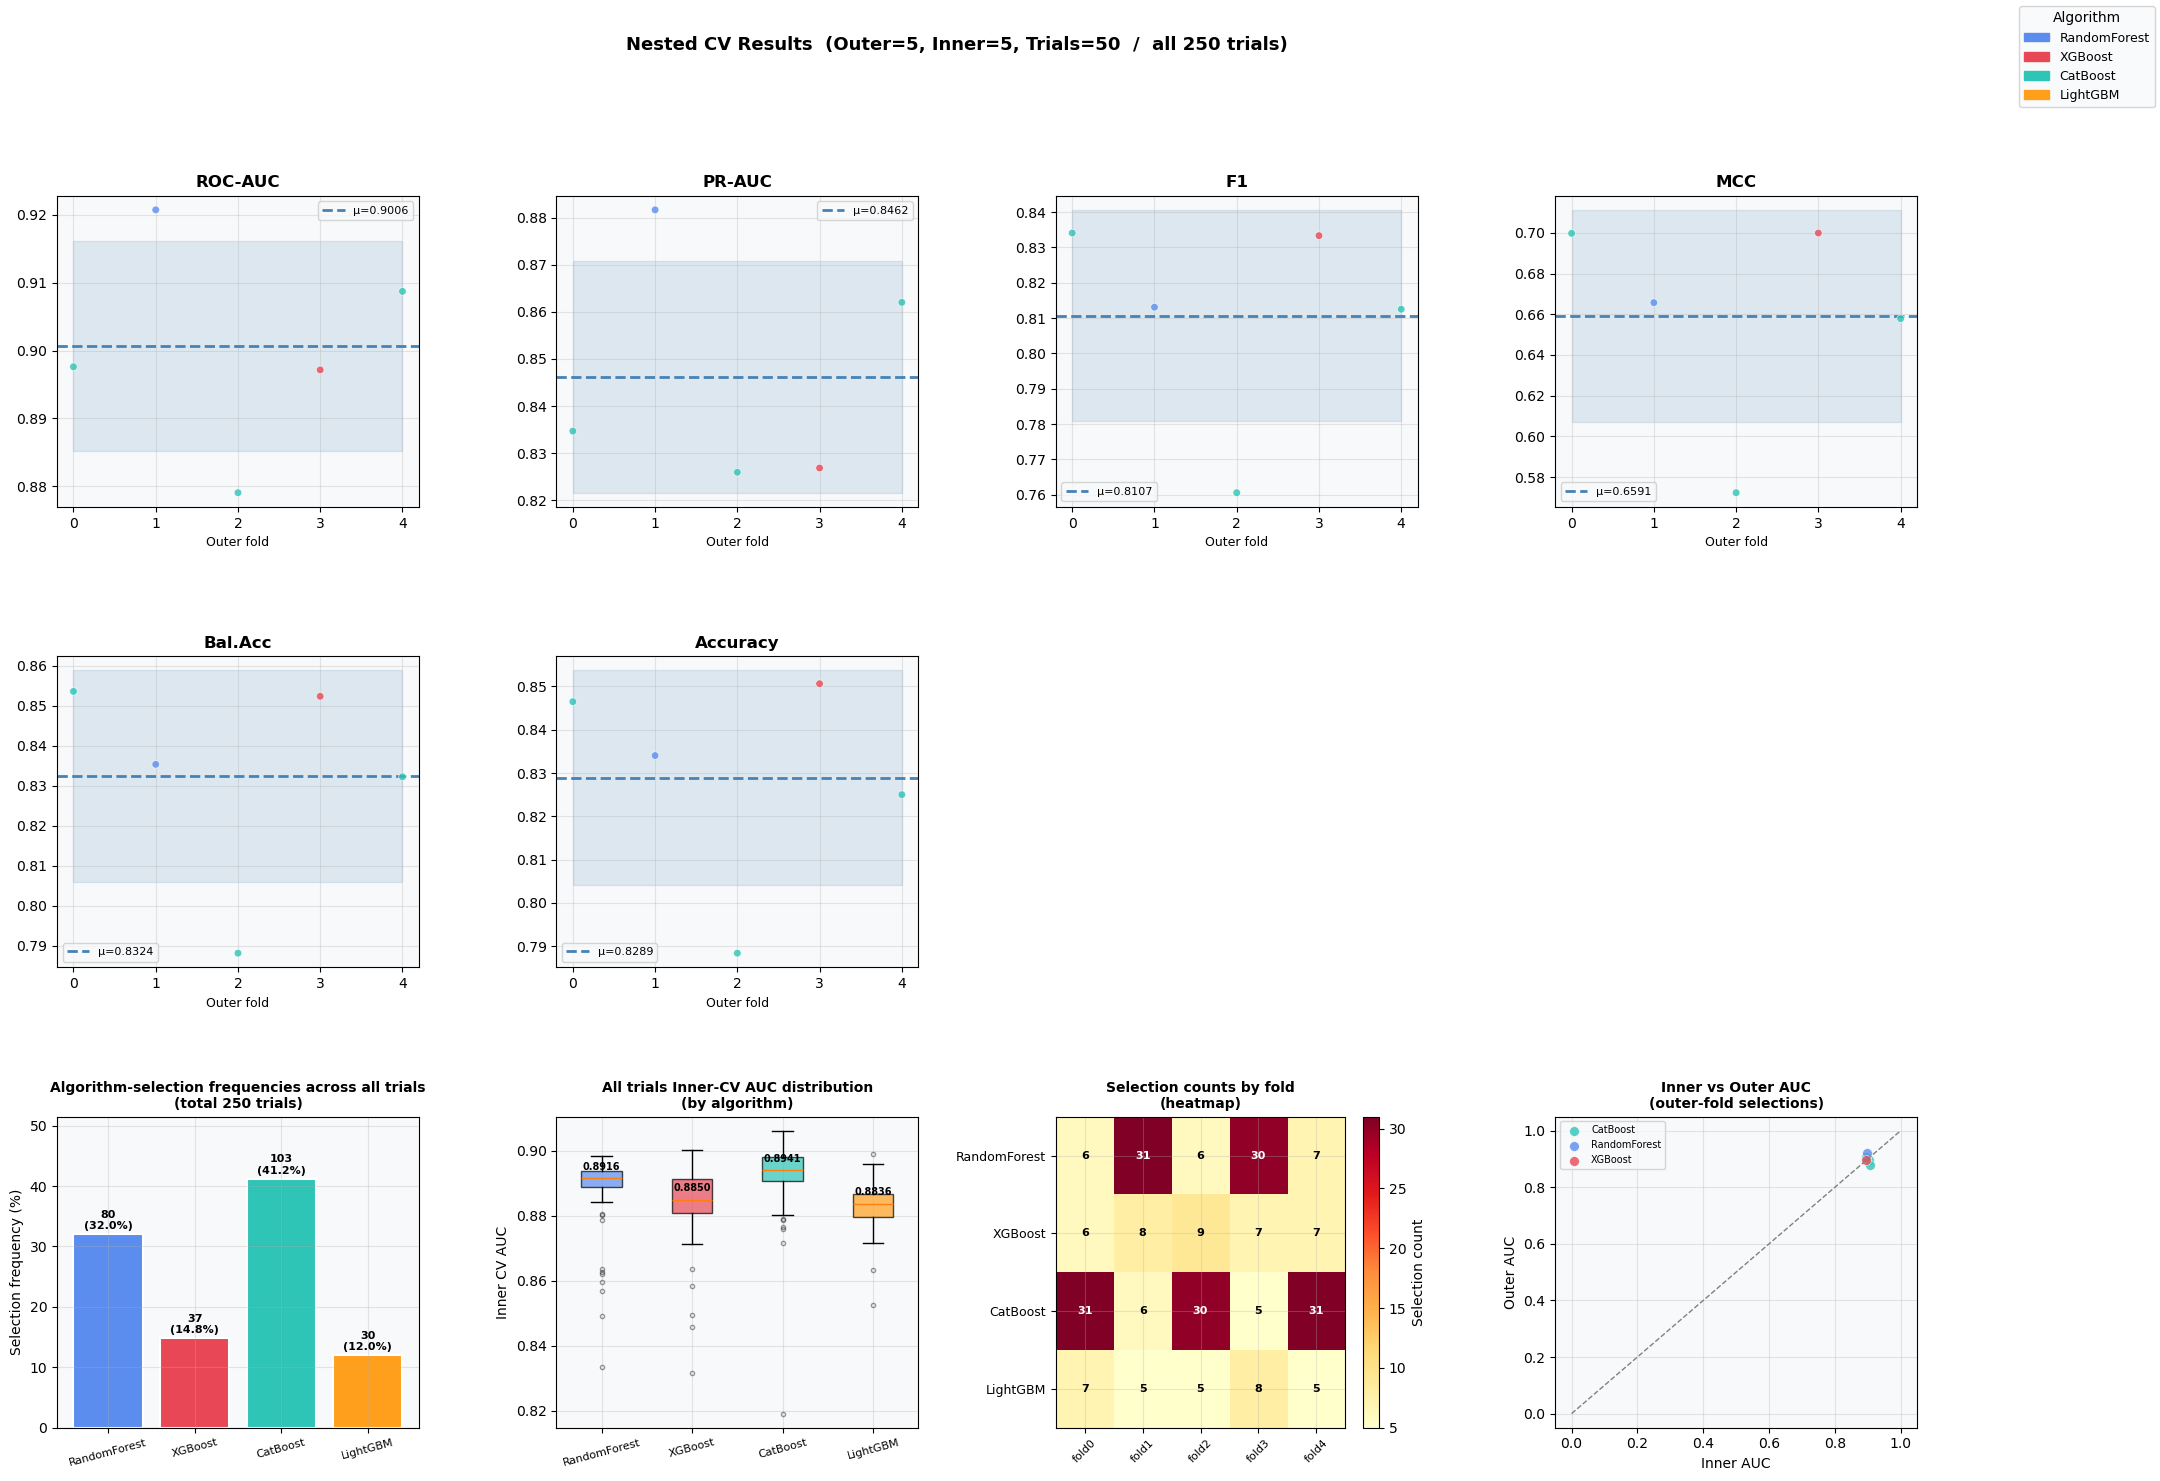

💾 Saved: 02_nested_cv_results.png


In [9]:
METRICS = ['roc_auc','pr_auc','f1','mcc','bal_acc','accuracy']
MLABELS = {'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','f1':'F1',
           'mcc':'MCC','bal_acc':'Bal.Acc','accuracy':'Accuracy'}

print('=' * 65)
print('  📊 NESTED CV SUMMARY')
print('=' * 65)
for m in METRICS:
    v = df_ncv[m]
    print(f'  {MLABELS[m]:12s}: {v.mean():.4f} ± {v.std():.4f}  [{v.min():.4f}–{v.max():.4f}]')
print('-' * 65)
algo_freq_ncv = df_ncv['algorithm'].value_counts()
algo_freq_all = df_all_trials['algorithm'].value_counts()
n_total       = len(df_all_trials)
print(f'  Outer-fold selections ({OUTER_SPLITS}fold):')
for a, cnt in algo_freq_ncv.items():
    print(f'    {a:15s}: {cnt} ({cnt/OUTER_SPLITS*100:.1f}%)')
print(f'  All trials ({n_total} trials = Outer{OUTER_SPLITS}×Trials{N_TRIALS}):')
for a, cnt in algo_freq_all.items():
    print(f'    {a:15s}: {cnt} ({cnt/n_total*100:.1f}%)')
print('=' * 65)

import matplotlib.patches as mpatches
algo_list   = ['RandomForest','XGBoost','CatBoost','LightGBM']
fold_colors = [PALETTE.get(a,'gray') for a in df_ncv['algorithm']]

fig = plt.figure(figsize=(24, 16))
gs  = fig.add_gridspec(3, 4, hspace=0.48, wspace=0.38)

# ── Rows 1-2: scatterplots for the six performance metrics ─────────────────────────
for i, m in enumerate(METRICS):
    ax = fig.add_subplot(gs[i//4, i%4])
    mv, sv = df_ncv[m].mean(), df_ncv[m].std()
    ax.fill_between(range(OUTER_SPLITS), mv-sv, mv+sv,
                    alpha=0.15, color='steelblue')
    ax.axhline(mv, color='steelblue', lw=2, linestyle='--',
               label=f'μ={mv:.4f}')
    ax.scatter(df_ncv['fold'], df_ncv[m], c=fold_colors,
               s=30, alpha=0.8, zorder=4, edgecolors='white', linewidth=0.5)
    ax.set_title(MLABELS[m], fontweight='bold')
    ax.set_xlabel('Outer fold', fontsize=9)
    ax.legend(fontsize=8)

# ── Row 3, left: algorithm-selection frequencies across all trials ──────────────────
ax_bar = fig.add_subplot(gs[2, 0])
algos_sorted = [a for a in algo_list if a in algo_freq_all.index]
counts = [algo_freq_all.get(a, 0) for a in algos_sorted]
pcts   = [c / n_total * 100 for c in counts]
bars   = ax_bar.bar(algos_sorted, pcts,
                    color=[PALETTE.get(a,'#999') for a in algos_sorted],
                    edgecolor='white', linewidth=1.5)
for bar, pct, cnt in zip(bars, pcts, counts):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{cnt}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_bar.set_ylabel('Selection frequency (%)')
ax_bar.set_title(f'Algorithm-selection frequencies across all trials\n(total {n_total} trials)',
                 fontweight='bold', fontsize=10)
ax_bar.set_xticklabels(algos_sorted, rotation=15, fontsize=8)
ax_bar.set_ylim(0, max(pcts) * 1.25)

# ── Row 3, center-left: boxplots of inner-CV AUC across all trials ───────────────────────
ax_box = fig.add_subplot(gs[2, 1])
data_auc = [df_all_trials[df_all_trials['algorithm']==a]['inner_auc'].dropna().values
            for a in algos_sorted]
bp = ax_box.boxplot(data_auc, labels=algos_sorted,
                    patch_artist=True, notch=False,
                    showfliers=True, flierprops={'markersize':3,'alpha':0.4})
for patch, a in zip(bp['boxes'], algos_sorted):
    patch.set_facecolor(PALETTE.get(a,'gray')); patch.set_alpha(0.7)
for i, (a, d) in enumerate(zip(algos_sorted, data_auc)):
    if len(d) > 0:
        ax_box.text(i+1, np.median(d)+0.002, f'{np.median(d):.4f}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')
ax_box.set_ylabel('Inner CV AUC')
ax_box.set_title('All trials Inner-CV AUC distribution\n(by algorithm)',
                 fontweight='bold', fontsize=10)
ax_box.set_xticklabels(algos_sorted, rotation=15, fontsize=8)

# ── Row 3, center-right: selection-frequency heatmap by fold ────────────────────────────
ax_heat = fig.add_subplot(gs[2, 2])
pivot = df_all_trials.groupby(['fold','algorithm']).size().unstack(fill_value=0)
for a in algo_list:
    if a not in pivot.columns:
        pivot[a] = 0
pivot = pivot[algo_list]
im = ax_heat.imshow(pivot.T.values, aspect='auto', cmap='YlOrRd',
                    interpolation='nearest')
ax_heat.set_xticks(range(len(pivot.index)))
ax_heat.set_xticklabels([f'fold{i}' for i in pivot.index], fontsize=8, rotation=45)
ax_heat.set_yticks(range(len(algo_list)))
ax_heat.set_yticklabels(algo_list, fontsize=9)
ax_heat.set_title('Selection counts by fold\n(heatmap)',
                  fontweight='bold', fontsize=10)
vmax = pivot.values.max()
for i in range(len(algo_list)):
    for j in range(len(pivot.index)):
        val = pivot.T.values[i, j]
        ax_heat.text(j, i, str(val), ha='center', va='center',
                     fontsize=8, fontweight='bold',
                     color='white' if val > vmax*0.6 else 'black')
plt.colorbar(im, ax=ax_heat, label='Selection count')

# ── Row 3, right: inner- versus outer-CV AUC ────────────────────────────────
ax_io = fig.add_subplot(gs[2, 3])
for a in algo_freq_ncv.index:
    sub = df_ncv[df_ncv['algorithm']==a]
    ax_io.scatter(sub['inner_auc'], sub['roc_auc'],
                  c=PALETTE.get(a,'gray'), label=a, alpha=0.8,
                  s=50, edgecolors='white', linewidth=0.5)
ax_io.plot([0,1],[0,1],'--', color='gray', lw=1)
ax_io.set_xlabel('Inner AUC'); ax_io.set_ylabel('Outer AUC')
ax_io.set_title('Inner vs Outer AUC\n(outer-fold selections)',
                fontweight='bold', fontsize=10)
ax_io.legend(fontsize=7)

patches = [mpatches.Patch(color=c, label=a) for a,c in PALETTE.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9, title='Algorithm')
fig.suptitle(
    f'Nested CV Results  (Outer={OUTER_SPLITS}, Inner={INNER_SPLITS}, Trials={N_TRIALS}  /  all {n_total} trials)',
    fontsize=13, fontweight='bold')
plt.savefig(str(RESULTS_DIR / '02_nested_cv_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Saved: 02_nested_cv_results.png')


## 9. Final Algorithm Selection


In [10]:
algo_stats = {}
for a in ['RandomForest','XGBoost','CatBoost','LightGBM']:
    sub = df_ncv[df_ncv['algorithm']==a]
    if len(sub) == 0: continue
    freq     = len(sub)
    mean_auc = sub['roc_auc'].mean()
    std_auc  = sub['roc_auc'].std()
    algo_stats[a] = {
        'freq'    : freq,
        'freq_pct': freq / OUTER_SPLITS,
        'mean_auc': mean_auc,
        'std_auc' : 0.0 if np.isnan(std_auc) else std_auc,
    }

algo_stats_df = pd.DataFrame(algo_stats).T.sort_values(
    ['freq', 'mean_auc'], ascending=[False, False]  # ① prioritize frequency; use mean AUC to break ties
)
BEST_ALGO = algo_stats_df.index[0]
# BEST_K is selected by the final Optuna optimization in Section 10

print('╔' + '═'*68 + '╗')
print('║  🏆 BEST ALGORITHM(frequency first; mean AUC breaks ties)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Best Algorithm : {BEST_ALGO}'.ljust(69) + '║')
print(f'║  Best k         : selected by Optuna in Section 10'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
print(f'║  {"Algorithm":15s} {"Frequency":>5} {"Frequency (%)":>7} {"AUC mean":>9} {"AUC std":>8}  ║')
print('╠' + '─'*68 + '╣')
for a, row in algo_stats_df.iterrows():
    mark = ' ← BEST' if a==BEST_ALGO else ''
    print(f'║  {a:15s} {row["freq"]:>5.0f} {row["freq_pct"]:>7.1%} '
          f'{row["mean_auc"]:>9.4f} {row["std_auc"]:>8.4f}{mark}'.ljust(69) + '║')
print('╚' + '═'*68 + '╝')


╔════════════════════════════════════════════════════════════════════╗
║  🏆 BEST ALGORITHM(frequency first; mean AUC breaks ties)           ║
╠════════════════════════════════════════════════════════════════════╣
║  Best Algorithm : CatBoost                                         ║
║  Best k         : selected by Optuna in Section 10                 ║
╠────────────────────────────────────────────────────────────────────╣
║  Algorithm       Frequency Frequency (%)  AUC mean  AUC std  ║
╠────────────────────────────────────────────────────────────────────╣
║  CatBoost            3   60.0%    0.8951   0.0150 ← BEST           ║
║  RandomForest        1   20.0%    0.9207   0.0000                  ║
║  XGBoost             1   20.0%    0.8971   0.0000                  ║
╚════════════════════════════════════════════════════════════════════╝


## 10. Final Hyperparameter Optimization


In [11]:
final_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print(f'🔧 Final optimization: {BEST_ALGO} | {INNER_SPLITS}-Fold CV | {N_TRIALS} trials')
print(f'   (the algorithm is fixed; k_best and the remaining hyperparameters are reoptimized with Optuna)')

def make_final_obj_with_k(X_tr, y_tr, algo, final_cv):
    """
    Fix the selected algorithm and reoptimize k_best and the remaining hyperparameters using the full dataset.
    Optuna also searches k_best to avoid selecting it from a single nested-CV fold.
    """
    def objective(trial):
        k          = trial.suggest_int('k_best', K_MIN, K_MAX_ACTUAL)
        trial_seed = RANDOM_STATE + trial.number
        return _cv_auc(
            trial, algo,
            SelectKBest(f_classif, k=k),
            X_tr, y_tr, final_cv,
            fold_seed=trial_seed
        )
    return objective

final_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10))
final_study.optimize(
    make_final_obj_with_k(X_train_val, y_train_val, BEST_ALGO, final_cv),
    n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

BEST_K = int(final_study.best_params['k_best'])

print(f'\n✅ Final optimization completed')
print(f'   Best inner ROC-AUC: {final_study.best_value:.4f}')
print(f'   Best k_best       : {BEST_K}')
print(f'   Best params       : {final_study.best_params}')


🔧 Final optimization: CatBoost | 5-Fold CV | 50 trials
   (the algorithm is fixed; k_best and the remaining hyperparameters are reoptimized with Optuna)


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Final optimization completed
   Best inner ROC-AUC: 0.9072
   Best k_best       : 214
   Best params       : {'k_best': 214, 'cb_iter': 453, 'cb_depth': 6, 'cb_lr': 0.016602796970044565, 'cb_l2': 0.14198142627465643, 'cb_border': 141, 'cb_bag': 0.04765125045540572}


## 10b. Final Model Training Using the Full Dataset


In [12]:
# Final model: impute NaN/Inf using full-training-set medians and save the imputation values
X_train_imputed = X_train_val.copy().astype(float)
X_train_imputed = np.where(np.isinf(X_train_imputed), np.nan, X_train_imputed)
train_medians   = np.nanmedian(X_train_imputed, axis=0)
train_medians   = np.where(np.isnan(train_medians), 0.0, train_medians)
for col in range(X_train_imputed.shape[1]):
    X_train_imputed[np.isnan(X_train_imputed[:, col]), col] = train_medians[col]

final_model    = get_model(final_study.best_trial, BEST_ALGO, seed=RANDOM_STATE)
final_scaler   = StandardScaler()
final_selector = SelectKBest(f_classif, k=BEST_K)

X_all_s = final_scaler.fit_transform(X_train_imputed)
X_all_k = final_selector.fit_transform(X_all_s, y_train_val)
final_model.fit(X_all_k, y_train_val)

sel_mask   = final_selector.get_support()
sel_feats  = [feature_names_clean[i] for i,s in enumerate(sel_mask) if s]
sel_scores = final_selector.scores_[sel_mask]
sel_df     = pd.DataFrame({'feature':sel_feats,'f_score':sel_scores})\
               .sort_values('f_score', ascending=False).reset_index(drop=True)
sel_df.to_csv(str(RESULTS_DIR / 'selected_features.csv'), index=False)

knn_ad = NearestNeighbors(n_neighbors=AD_K, n_jobs=-1)
knn_ad.fit(X_all_k)
d_train, _ = knn_ad.kneighbors(X_all_k)
dm_train   = d_train.mean(axis=1)
AD_THRESHOLD = float(dm_train.mean() + 3 * dm_train.std())

joblib.dump({
    'model'              : final_model,
    'scaler'             : final_scaler,
    'selector'           : final_selector,
    'knn_ad'             : knn_ad,
    'ad_threshold'       : AD_THRESHOLD,
    'algorithm'          : BEST_ALGO,
    'k_best'             : BEST_K,
    'feature_names_clean': feature_names_clean,
    'selected_feats'     : sel_feats,
    'pki_threshold'      : PKI_THRESHOLD,
    'mordred_3d'         : MORDRED_3D,
    'train_medians'      : train_medians,   # Used for NaN/Inf imputation during prediction
    'use_rdkit'          : USE_RDKIT,
    'use_mordred'        : USE_MORDRED,
    'use_morgan'         : USE_MORGAN,
    'use_maccs'          : USE_MACCS,
    'morgan_radius'      : MORGAN_RADIUS,
    'morgan_nbits'       : MORGAN_NBITS,
}, str(RESULTS_DIR / 'final_qsar_model.pkl'))

print(f'✅ Final model training completed({X_train_val.shape[0]:,} training samples)')
print(f'   Selected features : {len(sel_feats)}')
print(f'   AD threshold(μ+3σ): {AD_THRESHOLD:.4f}')
print(f'\n💾 Saved: final_qsar_model.pkl  /  selected_features.csv')
print('\nTop 15 selected features:')
print(sel_df.head(15).to_string(index=False))


✅ Final model training completed(1,204 training samples)
   Selected features : 214
   AD threshold(μ+3σ): 11.0803

💾 Saved: final_qsar_model.pkl  /  selected_features.csv

Top 15 selected features:
           feature    f_score
Mordred_nG12FHRing 193.912692
     Mordred_VE1_A 167.273091
 Mordred_nG12FRing 163.605888
    Mordred_Xch-4d  93.272072
  Mordred_SMR_VSA9  93.232719
       Mordred_IC1  81.198657
  Mordred_AATSC3dv  79.297145
    Mordred_SsssCH  75.688074
     Mordred_NdsCH  72.802235
    Mordred_Xch-5d  71.620738
   Mordred_MAXaaCH  71.105575
    Mordred_Xch-3d  70.479008
  Mordred_n5AHRing  69.662648
    Mordred_ATS3dv  67.795051
Mordred_PEOE_VSA13  64.374697


## 10c. Comparison and Selection of Applicability-domain Thresholds (Optional)

Change `AD_METHOD` and rerun this section to select a different threshold. Run this section immediately after Section 10b.

| `AD_METHOD` | Definition | Purpose |
|---|---|---|
| `'mean3sd'` | Mean + 3 standard deviations (default) | Automated statistical threshold |
| `'percentile'` | Selected percentile of training-set distances | More robust to outliers |
| `'mean_factor'` | Mean multiplied by a specified factor | Direct, intuitive adjustment |
| `'all'` | Comparison of all three methods | Used to select an appropriate method |


  🔬 Comparison of AD thresholds
  Training-set distance statistics:
    Mean: 4.8451
    Standard deviation: 2.0784
    Minimum: 0.0000
    Maximum: 24.0214
    Median: 4.5345

  Method          Threshold  Training compounds within AD (%)
  --------------- --------  ------------------
  mean3sd          11.0803               98.3%
  percentile        8.4022               94.9%
  mean_factor       7.2677               90.8%

AD_METHOD="all": visualizing all methods
Set AD_METHOD to the selected method and rerun this section


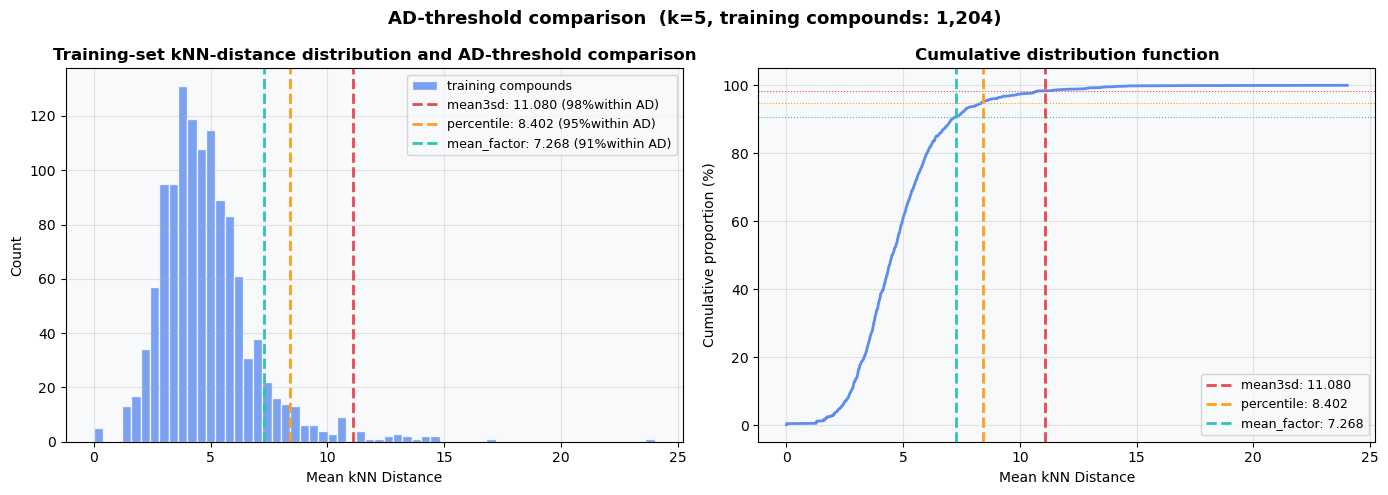

💾 Saved: ../results/10b_ad_threshold_comparison.png


In [13]:
# ==============================================================
# 🔬 AD analysis: comparison of multiple thresholds
# Run immediately after Section 10b
# knn_ad, X_all_k, and dm_train must already be defined
#
# Change AD_METHOD and rerun to select a different threshold
# ==============================================================

AD_METHOD      = 'all'   # 'mean3sd' / 'percentile' / 'mean_factor' / 'all'
AD_PERCENTILE  = 95      # Percentile used in percentile mode
AD_MEAN_FACTOR = 1.5     # Multiplier used in mean_factor mode

# ── Calculate the candidate thresholds ──────────────────────────────────────────────
thresholds = {
    'mean3sd'    : float(dm_train.mean() + 3 * dm_train.std()),
    'percentile' : float(np.percentile(dm_train, AD_PERCENTILE)),
    'mean_factor': float(dm_train.mean() * AD_MEAN_FACTOR),
}

print('='*62)
print('  🔬 Comparison of AD thresholds')
print('='*62)
print(f'  Training-set distance statistics:')
print(f'    Mean: {dm_train.mean():.4f}')
print(f'    Standard deviation: {dm_train.std():.4f}')
print(f'    Minimum: {dm_train.min():.4f}')
print(f'    Maximum: {dm_train.max():.4f}')
print(f'    Median: {np.median(dm_train):.4f}')
print()
print(f'  {"Method":<15} {"Threshold":>8}  {"Training compounds within AD (%)":>18}')
print(f'  {"-"*15} {"-"*8}  {"-"*18}')
for name, thr in thresholds.items():
    rate = (dm_train <= thr).mean() * 100
    print(f'  {name:<15} {thr:>8.4f}  {rate:>17.1f}%')
print('='*62)

# ── Update AD_THRESHOLD using the selected method ───────────────────────
if AD_METHOD == 'all':
    print()
    print('AD_METHOD="all": visualizing all methods')
    print('Set AD_METHOD to the selected method and rerun this section')
    AD_THRESHOLD_SELECTED = None
else:
    AD_THRESHOLD = thresholds[AD_METHOD]
    AD_THRESHOLD_SELECTED = AD_THRESHOLD
    print(f'\n✅ AD_THRESHOLD {AD_METHOD} ({AD_THRESHOLD:.4f}) was updated')

# ── Visualization: distance distribution and candidate thresholds ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(dm_train, bins=60, color='#5B8DEF', edgecolor='white',
             alpha=0.8, label='training compounds')
colors_thr = {'mean3sd':'#E84855', 'percentile':'#FF9F1C', 'mean_factor':'#2EC4B6'}
for name, thr in thresholds.items():
    rate = (dm_train <= thr).mean() * 100
    axes[0].axvline(thr, color=colors_thr[name], lw=2, linestyle='--',
                    label=f'{name}: {thr:.3f} ({rate:.0f}%within AD)')
axes[0].set_xlabel('Mean kNN Distance')
axes[0].set_ylabel('Count')
axes[0].set_title('Training-set kNN-distance distribution and AD-threshold comparison', fontweight='bold')
axes[0].legend(fontsize=9)

# Cumulative distribution function
sorted_d = np.sort(dm_train)
cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d) * 100
axes[1].plot(sorted_d, cdf, color='#5B8DEF', lw=2)
for name, thr in thresholds.items():
    rate = (dm_train <= thr).mean() * 100
    axes[1].axvline(thr, color=colors_thr[name], lw=2, linestyle='--',
                    label=f'{name}: {thr:.3f}')
    axes[1].axhline(rate, color=colors_thr[name], lw=0.8, linestyle=':')
axes[1].set_xlabel('Mean kNN Distance')
axes[1].set_ylabel('Cumulative proportion (%)')
axes[1].set_title('Cumulative distribution function', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(f'AD-threshold comparison  (k={AD_K}, training compounds: {len(dm_train):,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '10b_ad_threshold_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Saved: {RESULTS_DIR}/10b_ad_threshold_comparison.png')

# ── When AD_METHOD is not 'all', inspect the effect on predictions ─────
if AD_THRESHOLD_SELECTED is not None:
    print()
    print(f'Current AD_THRESHOLD = {AD_THRESHOLD:.4f} ({AD_METHOD})')
    print(f'Run the following code to update the model bundle with this threshold:')
    print()
    print('  _bundle[\'ad_threshold\'] = AD_THRESHOLD')
    print('  joblib.dump(_bundle, str(RESULTS_DIR / \'final_qsar_model.pkl\'))')
    print('  print(\'✅ The AD threshold in the model bundle was updated\')')


## 11. SHAP-based Feature Interpretation


Calculating SHAP values... algo=CatBoost  n=200
✅ SHAP calculation completed  shape=(200, 214)


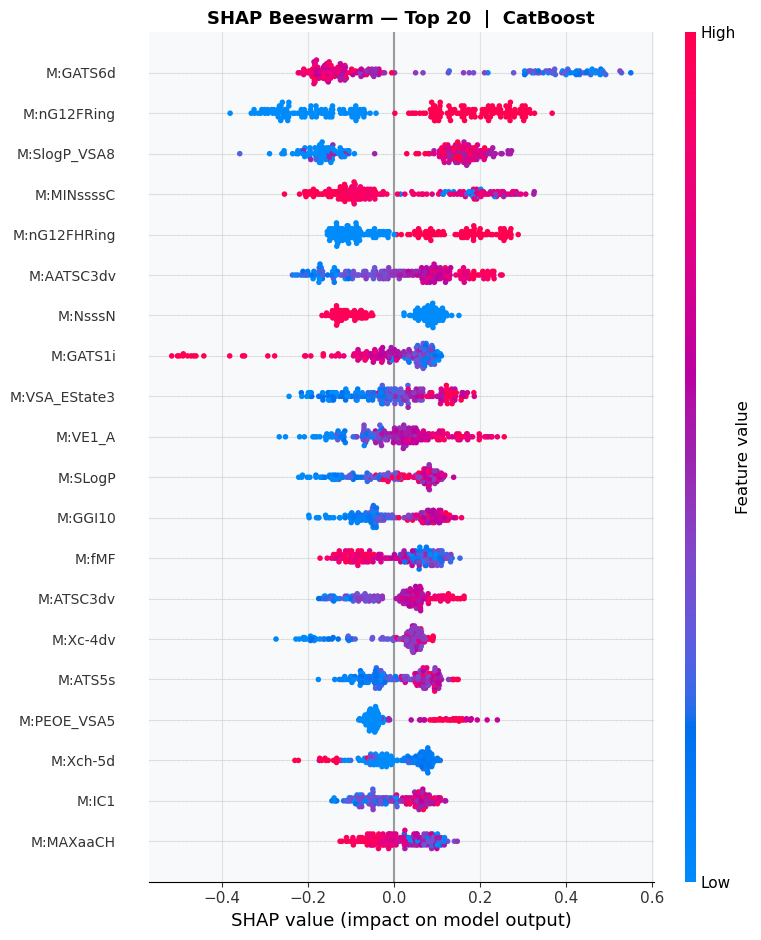

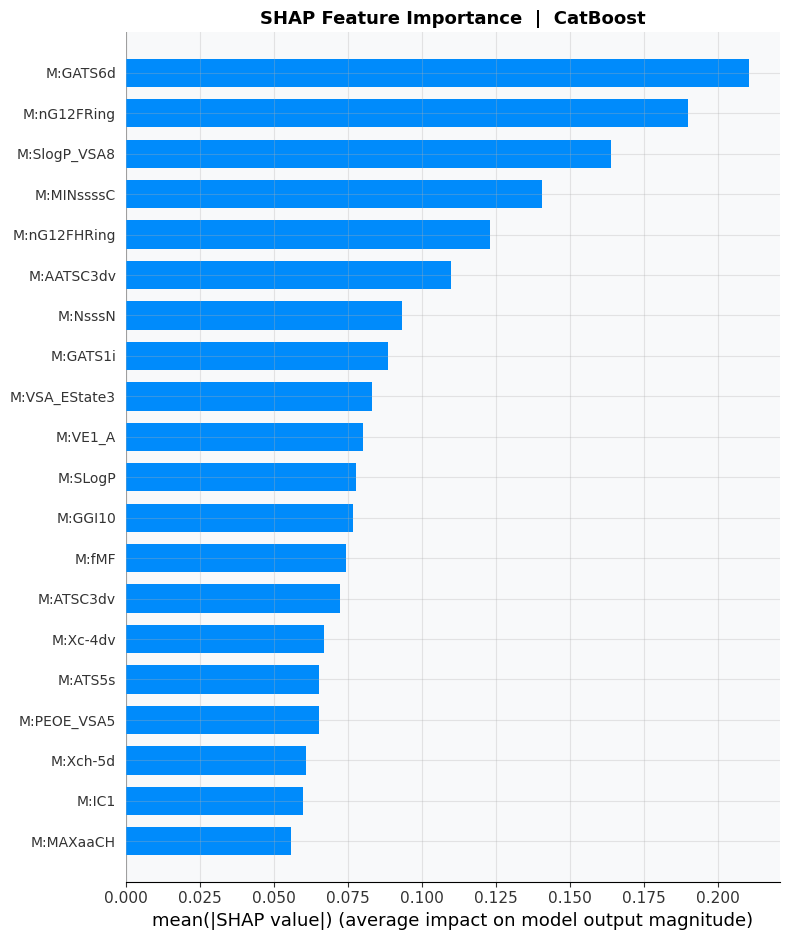

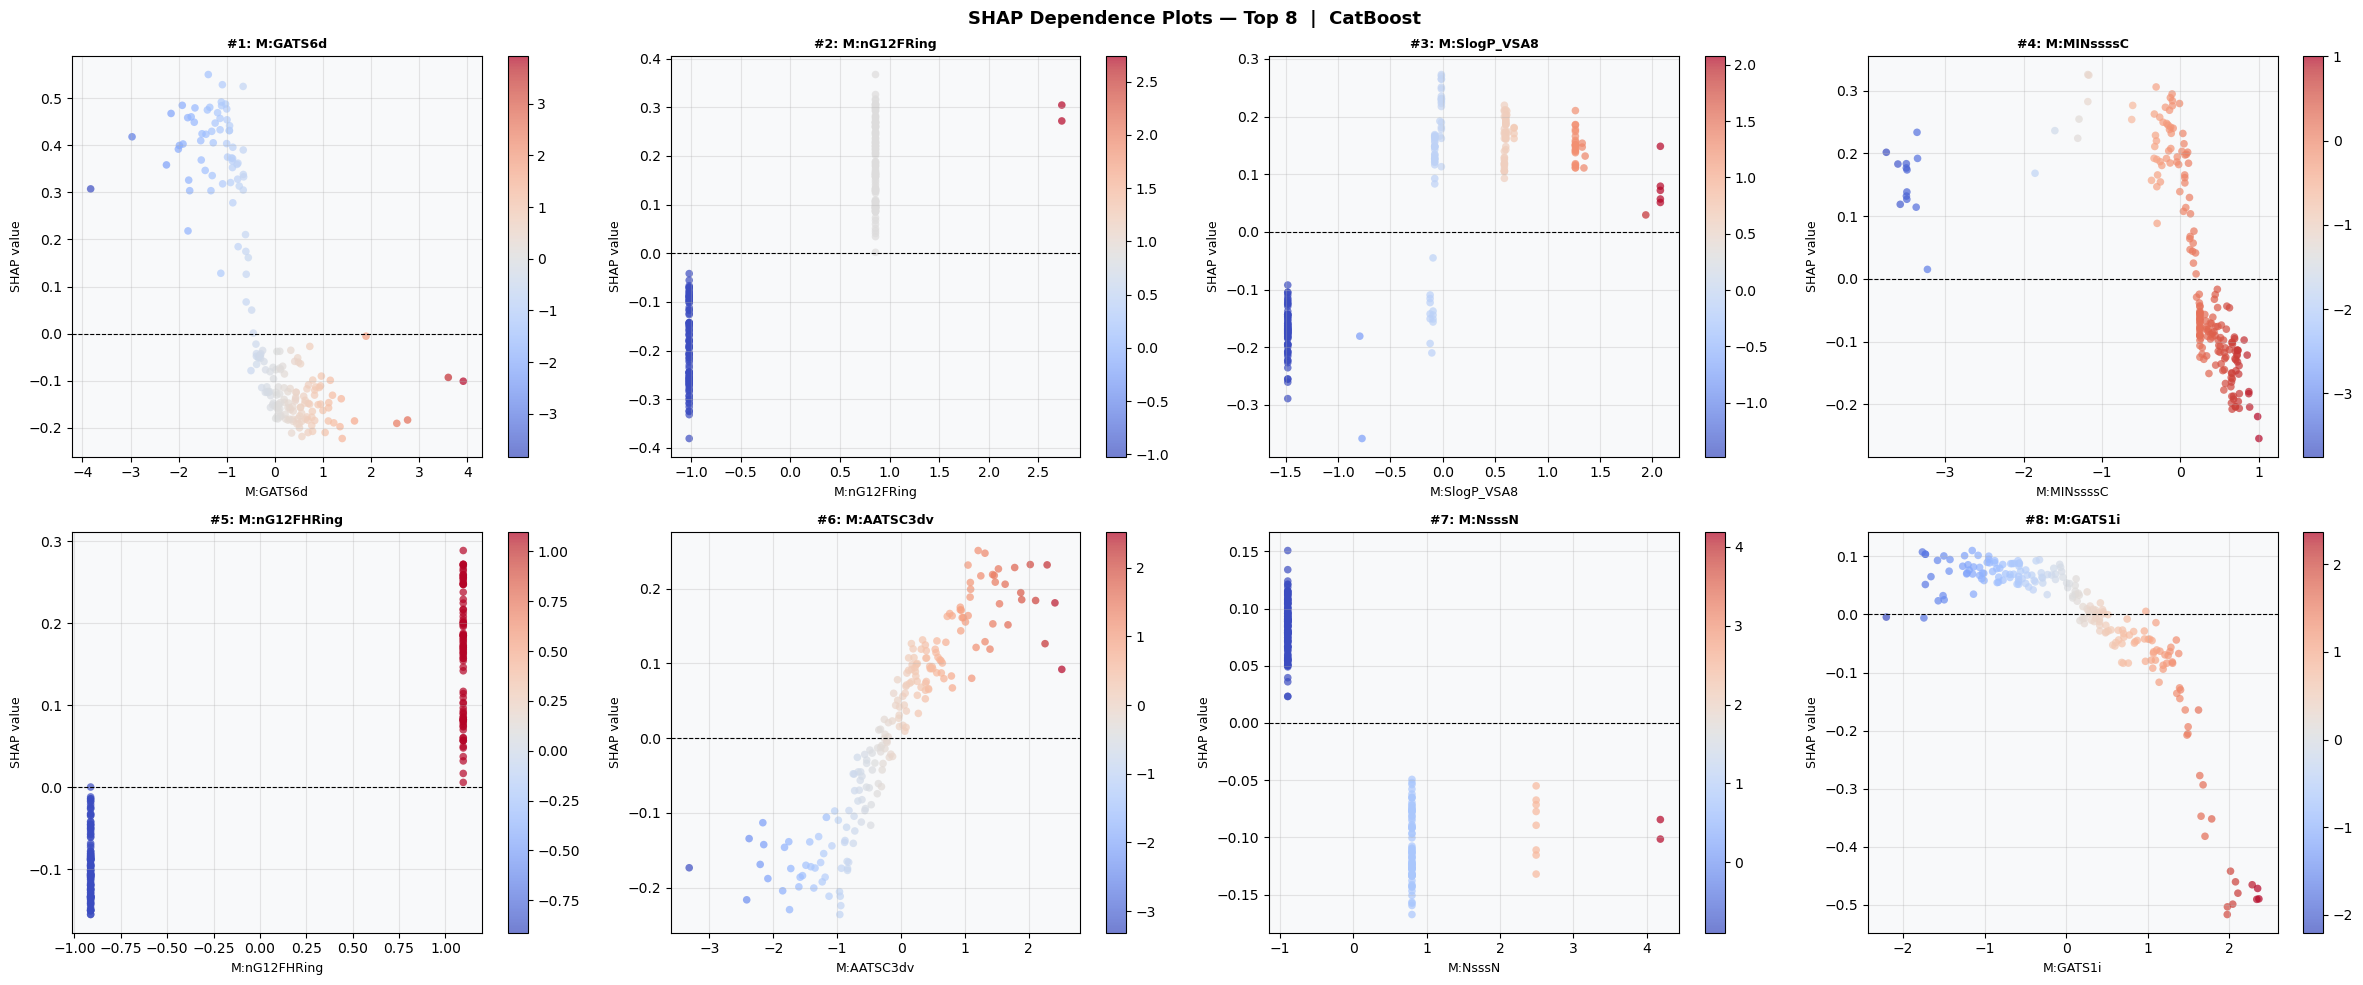

💾 Saved: 03a_shap_beeswarm.png / 03b_shap_importance.png / 04_shap_dependence.png


In [14]:
print(f'Calculating SHAP values... algo={BEST_ALGO}  n={SHAP_SAMPLES}')
rng      = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_all_k), min(SHAP_SAMPLES, len(X_all_k)), replace=False)
X_shap   = X_all_k[shap_idx].astype(np.float64)
bg_idx   = rng.choice(len(X_all_k), min(100, len(X_all_k)), replace=False)
X_bg     = X_all_k[bg_idx].astype(np.float64)
sfeats_s = [f.replace('RDKit_','R:').replace('Mordred_','M:') for f in sel_feats]

if BEST_ALGO == 'XGBoost':
    old_params = final_model.get_params()
    n_neg = float((y_train_val==0).sum()); n_pos = float((y_train_val==1).sum())
    _m = XGBClassifier(**{**old_params,'scale_pos_weight':n_neg/max(n_pos,1.0)})
    _m.fit(X_all_k, y_train_val)
    explainer   = shap.TreeExplainer(_m.get_booster(), data=X_bg)
    sv          = explainer(X_shap)
    shap_values = np.array(sv.values, dtype=float)
    if shap_values.ndim == 3: shap_values = shap_values[:,:,1]
elif BEST_ALGO == 'LightGBM':
    explainer   = shap.TreeExplainer(final_model, data=X_bg)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list): shap_values = shap_values[1]
    shap_values = np.array(shap_values, dtype=float)
else:
    explainer   = shap.TreeExplainer(final_model, data=X_bg)
    sv          = explainer(X_shap)
    shap_values = np.array(sv.values, dtype=float)
    if shap_values.ndim == 3: shap_values = shap_values[:,:,1]

shap_values = np.nan_to_num(shap_values, nan=0.0, posinf=0.0, neginf=0.0)
print(f'✅ SHAP calculation completed  shape={shap_values.shape}')

# ── Beeswarm plot(use a separate figure to provide sufficient width)────────────────────────
fig_bs, ax_bs = plt.subplots(figsize=(14, 8))
plt.sca(ax_bs)
shap.summary_plot(shap_values, X_shap, feature_names=sfeats_s,
                  max_display=20, show=False, plot_type='dot')
ax_bs.set_title(f'SHAP Beeswarm — Top 20  |  {BEST_ALGO}',
                fontweight='bold', fontsize=13)
ax_bs.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '03a_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Bar plot(use a separate figure to provide sufficient width)────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(12, 8))
plt.sca(ax_bar)
shap.summary_plot(shap_values, X_shap, feature_names=sfeats_s,
                  max_display=20, show=False, plot_type='bar')
ax_bar.set_title(f'SHAP Feature Importance  |  {BEST_ALGO}',
                 fontweight='bold', fontsize=13)
ax_bar.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '03b_shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Dependence plots — Top 8(two rows by four columns)─────────────────────────
top8_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-8:][::-1]
fig_dep, axes_dep = plt.subplots(2, 4, figsize=(24, 10))
axes_dep = axes_dep.flatten()
for i, fi in enumerate(top8_idx):
    sc = axes_dep[i].scatter(X_shap[:,fi], shap_values[:,fi],
                             c=X_shap[:,fi], cmap='coolwarm',
                             alpha=0.7, s=30, edgecolors='none')
    axes_dep[i].axhline(0, color='black', lw=0.8, linestyle='--')
    fname = sfeats_s[fi]
    axes_dep[i].set_xlabel(fname[:35], fontsize=9)
    axes_dep[i].set_ylabel('SHAP value', fontsize=9)
    axes_dep[i].set_title(f'#{i+1}: {fname[:30]}', fontweight='bold', fontsize=9)
    plt.colorbar(sc, ax=axes_dep[i])
plt.suptitle(f'SHAP Dependence Plots — Top 8  |  {BEST_ALGO}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '04_shap_dependence.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Saved: 03a_shap_beeswarm.png / 03b_shap_importance.png / 04_shap_dependence.png')


## 12. Final Report


In [15]:
print()
print('╔' + '═'*68 + '╗')
print('║  FINAL REPORT — v2 (full-data training)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
desc_used = [n for n,f in [('RDKit',USE_RDKIT),('Mordred',USE_MORDRED),
                            ('Morgan',USE_MORGAN),('MACCS',USE_MACCS)] if f]
print(f'║  Descriptor sets: {" + ".join(desc_used)}'.ljust(69) + '║')
print(f'║  Algorithm  : {BEST_ALGO}'.ljust(69) + '║')
print(f'║  k_best     : {BEST_K}'.ljust(69) + '║')
print(f'║  Train N    : {X_train_val.shape[0]:,} (full dataset)'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
print('║  Nested-CV performance estimates'.ljust(69) + '║')
for m in ['roc_auc','pr_auc','f1','mcc','bal_acc','accuracy']:
    v=df_ncv[m]; lbl={'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','f1':'F1',
                      'mcc':'MCC','bal_acc':'Bal.Acc','accuracy':'Accuracy'}[m]
    print(f'║    {lbl:10s}: {v.mean():.4f} ± {v.std():.4f}  [{v.min():.4f}-{v.max():.4f}]'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
algo_freq = df_ncv['algorithm'].value_counts()
print('║  Algorithm-selection frequency across outer folds'.ljust(69) + '║')
for a,cnt in algo_freq.items():
    print(f'║    {a:15s}: {cnt} ({cnt/OUTER_SPLITS*100:.1f}%)'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
algo_freq_all = df_all_trials['algorithm'].value_counts()
n_total = len(df_all_trials)
print(f'║  Algorithm-selection frequency across all trials (total {n_total} trials)'.ljust(69) + '║')
for a,cnt in algo_freq_all.items():
    print(f'║    {a:15s}: {cnt} ({cnt/n_total*100:.1f}%)'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
print(f'║  AD threshold(μ+3σ): {AD_THRESHOLD:.4f}'.ljust(69) + '║')
print(f'║  Output directory : {str(RESULTS_DIR.resolve())}'.ljust(69) + '║')
print('╠' + '─'*68 + '╣')
print('║  ⚠️  Performance values are nested-CV estimates, not independent test-set results'.ljust(69) + '║')
print('╚' + '═'*68 + '╝')



╔════════════════════════════════════════════════════════════════════╗
║  FINAL REPORT — v2 (full-data training)                            ║
╠════════════════════════════════════════════════════════════════════╣
║  Descriptor sets: Mordred                                          ║
║  Algorithm  : CatBoost                                             ║
║  k_best     : 214                                                  ║
║  Train N    : 1,204 (full dataset)                                 ║
╠────────────────────────────────────────────────────────────────────╣
║  Nested-CV performance estimates                                   ║
║    ROC-AUC   : 0.9006 ± 0.0155  [0.8790-0.9207]                    ║
║    PR-AUC    : 0.8462 ± 0.0246  [0.8259-0.8817]                    ║
║    F1        : 0.8107 ± 0.0299  [0.7606-0.8341]                    ║
║    MCC       : 0.6591 ± 0.0522  [0.5723-0.6999]                    ║
║    Bal.Acc   : 0.8324 ± 0.0265  [0.7881-0.8536]                    ║
║    

## 13. Prediction for FAERS Drugs and Evaluation Using Measured pKi Values

Select `'list'`, `'csv'`, or `'precomputed'` using `PREDICT_MODE`. The descriptor configuration is restored automatically from the saved model bundle. Agreement between measured and predicted classes is evaluated only for drugs with available measured pKi values. High GR affinity is defined as pKi ≥ 8.0.


final_qsar_model.pkl is being loaded...
✅ Model loaded
📄 CSV loaded: ../data/20260430_FAERS2025_druglist_cSMILES_real Pki.csv  (5267)

Input SMILES: 5267


Valid: 5267 / invalid: 0

Calculating descriptors...


✅ Preprocessing completed  shape=(5267, 572)

  🔮 Prediction summary
  Total compounds            : 5267
  Predicted high-affinity drugs (probability >= 0.5): 202
  Compounds within the AD    : 115 / 5267

  Top five predictions:
                                                                                           SMILES  pred_label  actual_pKi                  pred_class  prob_high_affinity  prob_low_affinity  knn_distance  in_AD    AD_note  actual_label correct
0         C[C@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@@]3(F)[C@@H](O)C[C@]2(C)[C@@]1(O)C(=O)CCl           1         NaN  High-affinity (pKi >= 8.0)              0.9763             0.0237       10.6427   True  Within AD          <NA>    <NA>
1     C[C@@H]1C[C@H]2[C@@H]3C[C@H](F)C4=CC(=O)C=C[C@]4(C)[C@@]3(F)[C@@H](O)C[C@]2(C)[C@H]1C(=O)CO           1         NaN  High-affinity (pKi >= 8.0)              0.9762             0.0238       10.0583   True  Within AD          <NA>    <NA>
2  C[C@H]1C[C@H]2[C@@H]3C[C@H](F)C4=CC(=O

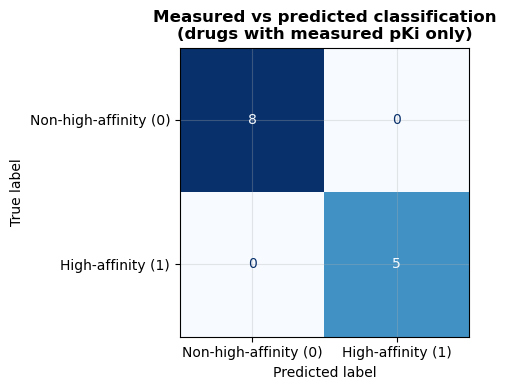

💾 Saved: ../results/06_measured_vs_predicted_cm.png


In [16]:
# ==============================================================
# 🔮 Prediction cell for new compounds and FAERS drugs
# ──────────────────────────────────────────────────────────────
# Input method A: provide a SMILES list directly
#   PREDICT_MODE = 'list'
#
# Input method B: load SMILES from a CSV file and calculate descriptors
#   PREDICT_MODE = 'csv'
#   PREDICT_CSV  = 'predict_input.csv'
#
# Input method C: load a CSV file containing precomputed descriptors
#   PREDICT_MODE            = 'precomputed'
#   PRECOMPUTED_PREDICT_CSV = 'predict_descriptors.csv'
# ==============================================================

PREDICT_MODE            = 'csv'
PREDICT_CSV             = DATA_DIR / '20260430_FAERS2025_druglist_cSMILES_real_pKi.csv'
PRECOMPUTED_PREDICT_CSV = DATA_DIR / '20260430_FAERS2025_druglist_real_pKi_predict_descriptors.csv'
SMILES_CSV_COL          = 'canonical_SMILES'
PKI_CSV_COL             = 'pKi'

PREDICT_SMILES = [
    'CC(=O)Oc1ccccc1C(=O)O',
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',
]

# ── Load the model ─────────────────────────────────────────────
try:
    _bundle
except NameError:
    print('final_qsar_model.pkl is being loaded...')
    _bundle = joblib.load(str(RESULTS_DIR / 'final_qsar_model.pkl'))
    final_model         = _bundle['model']
    final_scaler        = _bundle['scaler']
    final_selector      = _bundle['selector']
    knn_ad              = _bundle['knn_ad']
    AD_THRESHOLD        = _bundle['ad_threshold']
    BEST_ALGO           = _bundle['algorithm']
    BEST_K              = _bundle['k_best']
    feature_names_clean = _bundle['feature_names_clean']
    sel_feats           = _bundle['selected_feats']
    PKI_THRESHOLD       = _bundle['pki_threshold']
    MORDRED_3D          = _bundle.get('mordred_3d', False)
    train_medians       = _bundle.get('train_medians', None)
    # Restore descriptor settings from the model bundle
    USE_RDKIT   = _bundle.get('use_rdkit',   True)
    USE_MORDRED = _bundle.get('use_mordred', True)
    USE_MORGAN  = _bundle.get('use_morgan',  False)
    USE_MACCS   = _bundle.get('use_maccs',   False)
    MORGAN_RADIUS = _bundle.get('morgan_radius', 2)
    MORGAN_NBITS  = _bundle.get('morgan_nbits', 2048)
    print('✅ Model loaded')

# ── Resolve the input source ────────────────────────────────────────────
_actual_pki   = None
_skip_desc    = False
_precomp_feat = None

if PREDICT_MODE == 'list':
    print(f'📝 List input: {len(PREDICT_SMILES)}')
elif PREDICT_MODE == 'csv':
    _pred_df = pd.read_csv(PREDICT_CSV)
    if SMILES_CSV_COL not in _pred_df.columns:
        raise ValueError(f'SMILES column "{SMILES_CSV_COL}" was not found')
    PREDICT_SMILES = _pred_df[SMILES_CSV_COL].astype(str).tolist()
    _actual_pki    = _pred_df[PKI_CSV_COL].values if PKI_CSV_COL in _pred_df.columns else None
    print(f'📄 CSV loaded: {PREDICT_CSV}  ({len(PREDICT_SMILES)})')
elif PREDICT_MODE == 'precomputed':
    _pred_df = pd.read_csv(PRECOMPUTED_PREDICT_CSV)
    if SMILES_CSV_COL not in _pred_df.columns:
        raise ValueError(f'SMILES column "{SMILES_CSV_COL}" was not found')
    PREDICT_SMILES = _pred_df[SMILES_CSV_COL].astype(str).tolist()
    _actual_pki    = _pred_df[PKI_CSV_COL].values if PKI_CSV_COL in _pred_df.columns else None
    _exclude       = {SMILES_CSV_COL, PKI_CSV_COL, 'label'}
    _precomp_feat  = _pred_df[[c for c in _pred_df.columns if c not in _exclude]].copy()
    _skip_desc     = True
    print(f'📊 Precomputed-descriptor CSV: {PRECOMPUTED_PREDICT_CSV}  ({len(PREDICT_SMILES)})')
else:
    raise ValueError(f'PREDICT_MODE "{PREDICT_MODE}" is invalid')

# ── SMILES validation ────────────────────────────────────────────────
# Suppress expected RDKit/Mordred numerical warnings during descriptor calculation.
warnings.filterwarnings('ignore', category=RuntimeWarning)
RDLogger.DisableLog('rdApp.warning')
print(f'\nInput SMILES: {len(PREDICT_SMILES)}')
valid_smiles, mols, valid_idx = [], [], []
for i, smi in enumerate(PREDICT_SMILES):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        valid_smiles.append(smi); mols.append(mol); valid_idx.append(i)
    else:
        print(f'  ⚠️  Invalid SMILES (index={i}): {smi}')
print(f'Valid: {len(valid_smiles)} / invalid: {len(PREDICT_SMILES)-len(valid_smiles)}')
_actual_pki_valid = _actual_pki[valid_idx] if _actual_pki is not None else None

# ── Calculate descriptors or format the precomputed-descriptor CSV ────────────────────────────
if _skip_desc:
    print('\n⏭️  Descriptor calculation skipped (using the precomputed CSV)')
    df_pred_feat = _precomp_feat.iloc[valid_idx].reset_index(drop=True)
    df_pred_feat = df_pred_feat.astype(str).apply(pd.to_numeric, errors='coerce')
    missing_cols = [c for c in feature_names_clean if c not in df_pred_feat.columns]
    extra_cols   = [c for c in df_pred_feat.columns if c not in feature_names_clean]
    if missing_cols:
        print(f'  ⚠️  Training features missing: {len(missing_cols)} features (imputed using training medians)')
    if extra_cols:
        print(f'  ℹ️  Extra features ignored: {len(extra_cols)} features')
else:
    print('\nCalculating descriptors...')
    desc_frames_pred = []

    if USE_RDKIT:
        rdkit_desc_names = [d[0] for d in Descriptors.descList]
        calc_rdkit = MoleculeDescriptors.MolecularDescriptorCalculator(rdkit_desc_names)
        rdkit_rows = []
        for mol in tqdm(mols, desc='RDKit', ncols=70):
            try:    vals = list(calc_rdkit.CalcDescriptors(mol))
            except: vals = [np.nan]*len(rdkit_desc_names)
            rdkit_rows.append(vals)
        desc_frames_pred.append(
            pd.DataFrame(rdkit_rows, columns=[f'RDKit_{n}' for n in rdkit_desc_names]))

    if USE_MORDRED:
        calc_mordred = Calculator(mordred_descs, ignore_3D=(not MORDRED_3D))
        df_pred_mord = calc_mordred.pandas(mols, quiet=True)
        df_pred_mord.columns = [f'Mordred_{c}' for c in df_pred_mord.columns]
        df_pred_mord = df_pred_mord.astype(str).apply(pd.to_numeric, errors='coerce')
        desc_frames_pred.append(df_pred_mord)

    if USE_MORGAN:
        ecfp_name = f'ECFP{MORGAN_RADIUS*2}'
        morgan_rows = []
        for mol in tqdm(mols, desc='Morgan', ncols=70):
            try:
                fp = AllChem.GetMorganFingerprintAsBitVect(
                    mol, radius=MORGAN_RADIUS, nBits=MORGAN_NBITS)
                vals = list(fp)
            except:
                vals = [0]*MORGAN_NBITS
            morgan_rows.append(vals)
        desc_frames_pred.append(
            pd.DataFrame(morgan_rows,
                         columns=[f'Morgan_{ecfp_name}_{i}' for i in range(MORGAN_NBITS)]))

    if USE_MACCS:
        maccs_rows = []
        for mol in tqdm(mols, desc='MACCS', ncols=70):
            try:
                fp = MACCSkeys.GenMACCSKeys(mol)
                vals = list(fp)
            except:
                vals = [0]*167
            maccs_rows.append(vals)
        desc_frames_pred.append(
            pd.DataFrame(maccs_rows,
                         columns=[f'MACCS_{i}' for i in range(len(maccs_rows[0]))]))

    df_pred_feat = pd.concat(desc_frames_pred, axis=1)

# ── Align columns with feature_names_clean ──────────────────────────
df_pred_aligned = df_pred_feat.reindex(columns=feature_names_clean)

# ── Impute NaN/Inf using training-set medians────────────────────
X_pred_raw = df_pred_aligned.replace([np.inf, -np.inf], np.nan).values.astype(float)
if train_medians is not None:
    for col in range(X_pred_raw.shape[1]):
        mask = np.isnan(X_pred_raw[:, col])
        if mask.any():
            X_pred_raw[mask, col] = train_medians[col] if col < len(train_medians) else 0.0
else:
    print('  ⚠️  train_medians unavailable; using prediction-set medians for compatibility with an older model')
    for col in range(X_pred_raw.shape[1]):
        mask = np.isnan(X_pred_raw[:, col])
        if mask.any():
            X_pred_raw[mask, col] = np.nanmedian(X_pred_raw[:, col]) if not np.all(mask) else 0.0

nan_remaining = np.isnan(X_pred_raw).sum()
if nan_remaining > 0:
    print(f'  ⚠️  NaN values remain after imputation: {nan_remaining} values; replacing them with 0')
    X_pred_raw = np.nan_to_num(X_pred_raw, nan=0.0)

print(f'✅ Preprocessing completed  shape={X_pred_raw.shape}')

# ── Scaling, feature selection, and prediction ─────────────────────────
X_pred_s = final_scaler.transform(X_pred_raw)
X_pred_k = final_selector.transform(X_pred_s)
y_proba  = final_model.predict_proba(X_pred_k)[:,1]
y_pred   = (y_proba >= 0.5).astype(int)

# ── Applicability-domain assessment ────────────────────────────────────────────────────
d_pred, _ = knn_ad.kneighbors(X_pred_k)
dm_pred   = d_pred.mean(axis=1)
in_ad     = dm_pred <= AD_THRESHOLD

# ── Results ──────────────────────────────────────────────────────
df_result = pd.DataFrame({
    'SMILES'            : valid_smiles,
    'pred_label'        : y_pred,
    'pred_class'        : ['High-affinity (pKi >= 8.0)' if p==1 else 'Non-high-affinity (pKi < 8.0)' for p in y_pred],
    'prob_high_affinity': np.round(y_proba, 4),
    'prob_low_affinity' : np.round(1-y_proba, 4),
    'knn_distance'      : np.round(dm_pred, 4),
    'in_AD'             : in_ad,
    'AD_note'           : ['Within AD' if a else 'Outside AD' for a in in_ad],
})
# ── Add comparison with measured pKi values ────────────────────────────────
# Set actual_label and correct to NA when measured pKi is unavailable
if _actual_pki_valid is not None:
    actual_pki_numeric = pd.to_numeric(
        pd.Series(_actual_pki_valid),
        errors='coerce'
    ).to_numpy()

    df_result.insert(
        2,
        'actual_pKi',
        np.round(actual_pki_numeric, 4)
    )

    df_result['actual_label'] = pd.Series(
        pd.NA,
        index=df_result.index,
        dtype='Int64'
    )
    df_result['correct'] = pd.Series(
        pd.NA,
        index=df_result.index,
        dtype='object'
    )

    measured_mask = df_result['actual_pKi'].notna()
    df_result.loc[measured_mask, 'actual_label'] = (
        df_result.loc[measured_mask, 'actual_pKi'] >= PKI_THRESHOLD
    ).astype(int).values

    df_result.loc[measured_mask, 'correct'] = np.where(
        df_result.loc[measured_mask, 'pred_label'].astype(int).values
        == df_result.loc[measured_mask, 'actual_label'].astype(int).values,
        '✅',
        '❌'
    )
df_result = df_result.sort_values('prob_high_affinity', ascending=False).reset_index(drop=True)
df_result.to_csv(str(RESULTS_DIR / 'prediction_results.csv'), index=False)

print()
print('='*72)
print('  🔮 Prediction summary')
print('='*72)
print(f'  Total compounds            : {len(df_result)}')
print(f'  Predicted high-affinity drugs (probability >= 0.5): {(y_pred==1).sum()}')
print(f'  Compounds within the AD    : {in_ad.sum()} / {len(in_ad)}')
print()
print(f'  Top five predictions:')
print(df_result.head(5).to_string(index=True))
print(f'\n💾 All predictions: {RESULTS_DIR}/prediction_results.csv')


# ── Evaluate agreement only for drugs with measured pKi values ─────────────────────
if 'actual_pKi' in df_result.columns:
    eval_df = df_result.dropna(subset=['actual_pKi']).copy()

    if len(eval_df) > 0:
        eval_df['actual_label'] = (
            eval_df['actual_pKi'] >= PKI_THRESHOLD
        ).astype(int)
        eval_df['correct'] = (
            eval_df['pred_label'].astype(int)
            == eval_df['actual_label'].astype(int)
        )

        print()
        print('=' * 60)
        print('  Measured pKi vs predicted classification')
        print('=' * 60)
        print(f'  Measured pKi available: {len(eval_df)} drugs')
        print(
            f"  Concordant classifications: "
            f"{eval_df['correct'].sum()} / {len(eval_df)}"
        )
        print()

        concordance_table = pd.crosstab(
            eval_df['actual_label'],
            eval_df['pred_label'],
            rownames=['Measured class'],
            colnames=['Predicted class'],
            margins=True
        )
        print(concordance_table)

        if len(eval_df) != 13:
            print(
                f'\n⚠️ Expected 13 drugs with measured pKi, '
                f'but found {len(eval_df)}.'
            )

        y_true_pred = eval_df['actual_label'].astype(int).to_numpy()
        y_pred_arr = eval_df['pred_label'].astype(int).to_numpy()
        y_prob_arr = eval_df['prob_high_affinity'].astype(float).to_numpy()

        print()
        print(f'  Accuracy : {accuracy_score(y_true_pred, y_pred_arr):.4f}')
        print(f'  ROC-AUC  : {roc_auc_score(y_true_pred, y_prob_arr):.4f}')
        print(f'  F1       : {f1_score(y_true_pred, y_pred_arr, zero_division=0):.4f}')
        print(
            f'  Bal.Acc  : '
            f'{balanced_accuracy_score(y_true_pred, y_pred_arr):.4f}'
        )
        print('=' * 60)

        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix(y_true_pred, y_pred_arr),
            display_labels=['Non-high-affinity (0)', 'High-affinity (1)']
        ).plot(
            ax=ax_cm,
            cmap='Blues',
            colorbar=False
        )
        ax_cm.set_title(
            'Measured vs predicted classification\n'
            '(drugs with measured pKi only)',
            fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(
            str(RESULTS_DIR / '06_measured_vs_predicted_cm.png'),
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()
        print(
            f'💾 Saved: '
            f'{RESULTS_DIR}/06_measured_vs_predicted_cm.png'
        )
    else:
        print('Measured pKi values were not available.')
